In [10]:
from fingerprint import AudioFingerprinter
import matplotlib.pyplot as plt
import numpy as np
import librosa.display




In [11]:
fp = AudioFingerprinter()
y, sr = fp.preprocess("songs/Neelothi.mp3")
t = np.linspace(0, len(y)/sr, num=len(y))

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Length (seconds): 6051328
Sample Rate: 22050
Max amplitude: 0.8290968
Min amplitude: -0.7098016


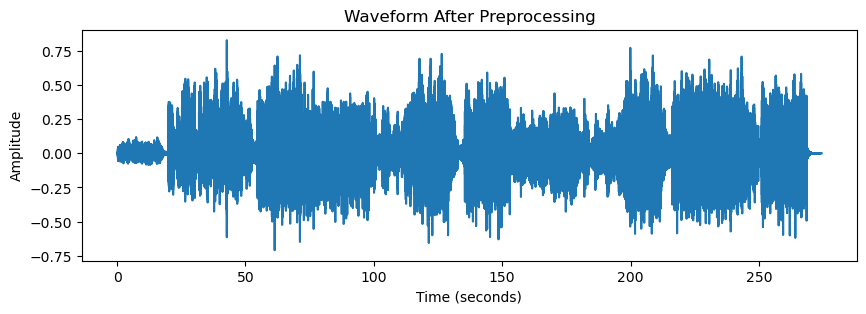

In [12]:
print("Length (seconds):", len(t))
print("Sample Rate:", sr)
print("Max amplitude:", y.max())
print("Min amplitude:", y.min())


plt.figure(figsize=(10, 3))
plt.plot(t, y)
plt.title("Waveform After Preprocessing")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


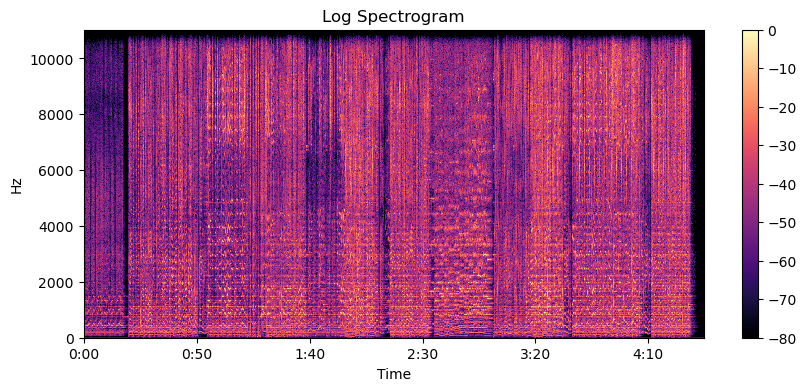

In [13]:
S_db = fp.generate_spectrogram(y)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=fp.hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()
plt.title("Log Spectrogram")
plt.show()

FFT bins         : 1025
Hz per bin       : 10.76 Hz
Spectrogram min  : 0.0 Hz
Spectrogram max  : 11014.2 Hz

Active freq min  : 0.0 Hz  (bin 0)
Active freq max  : 10777.6 Hz  (bin 1002)
Active bandwidth : 10777.6 Hz


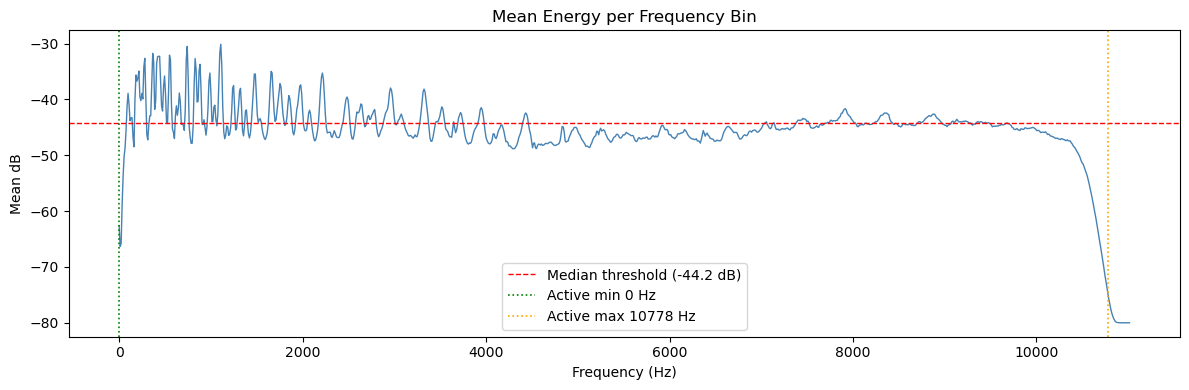

In [14]:
# ── Spectrogram frequency range analysis ────────────────────────────────────
n_freq_bins = S_db.shape[0]          # number of FFT frequency bins
freq_resolution = (sr / 2) / n_freq_bins   # Hz per bin

all_freqs_hz = np.arange(n_freq_bins) * freq_resolution

print(f"FFT bins         : {n_freq_bins}")
print(f"Hz per bin       : {freq_resolution:.2f} Hz")
print(f"Spectrogram min  : {all_freqs_hz[0]:.1f} Hz")
print(f"Spectrogram max  : {all_freqs_hz[-1]:.1f} Hz")
print()

# Energy-weighted min/max — find the lowest and highest frequency bins
# that actually carry significant energy (above median dB level)
energy_threshold = np.median(S_db)
active_bins = np.where(np.any(S_db > energy_threshold, axis=1))[0]

if len(active_bins):
    active_min_hz = active_bins[0]  * freq_resolution
    active_max_hz = active_bins[-1] * freq_resolution
    print(f"Active freq min  : {active_min_hz:.1f} Hz  (bin {active_bins[0]})")
    print(f"Active freq max  : {active_max_hz:.1f} Hz  (bin {active_bins[-1]})")
    print(f"Active bandwidth : {active_max_hz - active_min_hz:.1f} Hz")

# ── Plot energy per frequency bin ────────────────────────────────────────────
mean_energy = S_db.mean(axis=1)    # average dB across time for each freq bin

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_freqs_hz, mean_energy, color='steelblue', linewidth=1)
ax.axhline(energy_threshold, color='red', linestyle='--', linewidth=1,
           label=f'Median threshold ({energy_threshold:.1f} dB)')
if len(active_bins):
    ax.axvline(active_min_hz, color='green', linestyle=':', linewidth=1.2, label=f'Active min {active_min_hz:.0f} Hz')
    ax.axvline(active_max_hz, color='orange', linestyle=':', linewidth=1.2, label=f'Active max {active_max_hz:.0f} Hz')
ax.set_title("Mean Energy per Frequency Bin")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean dB")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
peaks = fp.find_peaks(S_db)
print("Peaks (time_idx, freq_idx):", peaks)

print("Number of peaks:", len(peaks))

Peaks (time_idx, freq_idx): [(np.int64(0), np.int64(816)), (np.int64(0), np.int64(11648)), (np.int64(0), np.int64(11669)), (np.int64(0), np.int64(11691)), (np.int64(0), np.int64(11711)), (np.int64(0), np.int64(11737)), (np.int64(0), np.int64(11768)), (np.int64(0), np.int64(11786)), (np.int64(4), np.int64(3113)), (np.int64(4), np.int64(3218)), (np.int64(4), np.int64(3440)), (np.int64(4), np.int64(3453)), (np.int64(4), np.int64(3641)), (np.int64(4), np.int64(3829)), (np.int64(5), np.int64(3264)), (np.int64(5), np.int64(3416)), (np.int64(5), np.int64(3840)), (np.int64(5), np.int64(5088)), (np.int64(5), np.int64(5104)), (np.int64(5), np.int64(5156)), (np.int64(5), np.int64(5573)), (np.int64(5), np.int64(5611)), (np.int64(5), np.int64(8671)), (np.int64(5), np.int64(8728)), (np.int64(5), np.int64(9144)), (np.int64(5), np.int64(9182)), (np.int64(6), np.int64(3146)), (np.int64(6), np.int64(3476)), (np.int64(6), np.int64(4191)), (np.int64(6), np.int64(4416)), (np.int64(6), np.int64(4791)), (np.

## Percentile-Based Peak Threshold Experiment

The current `find_peaks` applies a **column-wise 75th-percentile** threshold — for each time frame, only bins above the 75th percentile of that frame's energy are kept as candidate peaks.

Here we sweep the percentile from **50 → 95** to see:
- How peak count changes
- How the constellation map density changes

Lower percentile → more peaks (noisier, but more coverage)  
Higher percentile → fewer, sharper peaks (cleaner, but may miss quiet passages)


In [16]:
from scipy.ndimage import maximum_filter

def find_peaks_percentile(S_db, percentile=75, neighborhood=(20, 20)):
    """Peak finder with a tunable column-wise percentile threshold."""
    local_max = maximum_filter(S_db, size=neighborhood)
    detected  = S_db == local_max
    threshold = np.percentile(S_db, percentile, axis=0)
    threshold_mask = S_db > threshold[np.newaxis, :]
    freq_idx, time_idx = np.where(detected & threshold_mask)
    return list(zip(freq_idx, time_idx))


# ── Sweep percentiles ────────────────────────────────────────────────────────
percentiles = [50, 65, 75, 85, 90, 95]
results = {}

print(f"{'Percentile':>12}  {'Peaks':>8}  {'Hashes':>8}")
print("-" * 34)
for p in percentiles:
    ps = find_peaks_percentile(S_db, percentile=p)
    hs = fp.generate_hashes(ps)
    results[p] = (ps, hs)
    print(f"{p:>12}  {len(ps):>8}  {len(hs):>8}")


  Percentile     Peaks    Hashes
----------------------------------
          50     20852    166504
          65     20576    164905
          75     20040    162006
          85     18602    153491
          90     17131    144189
          95     13805    121100


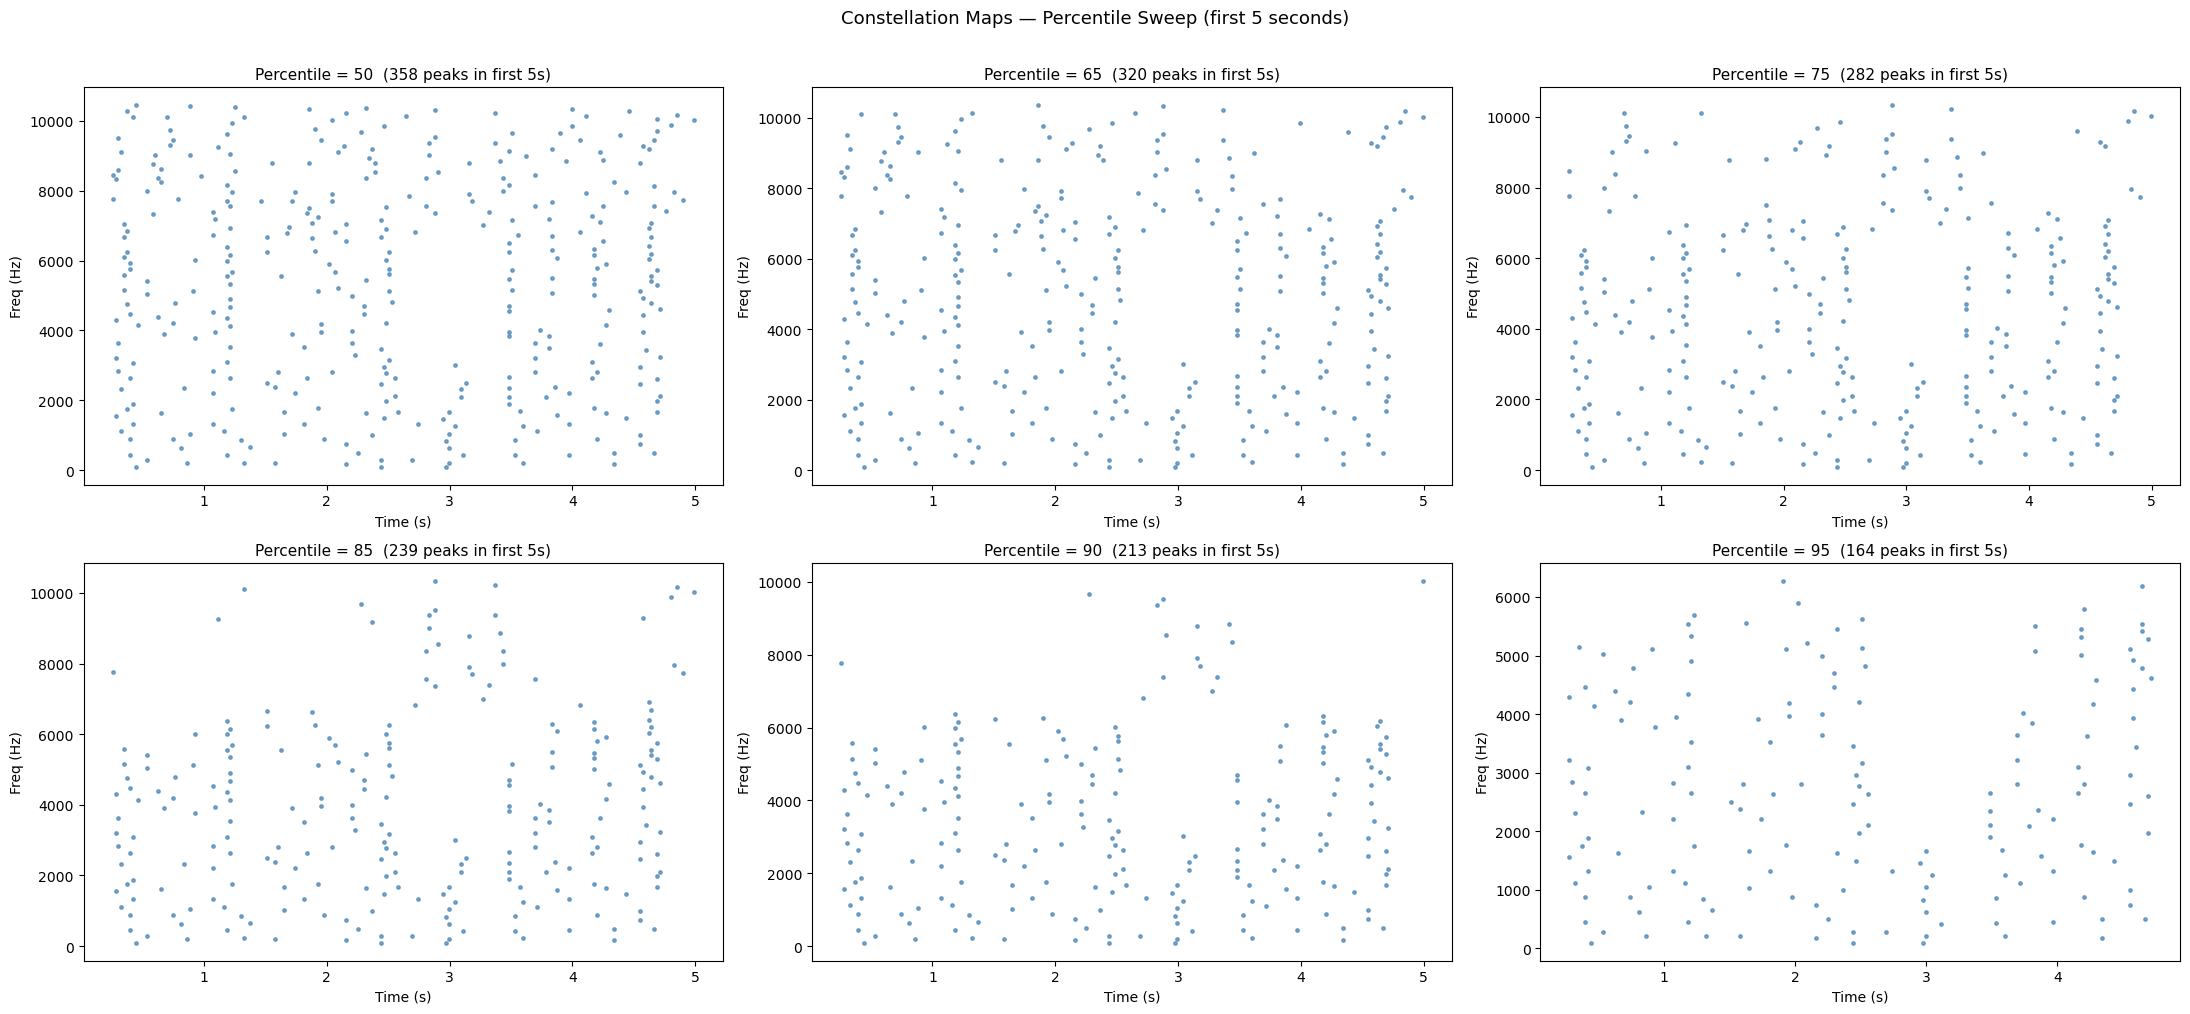

In [17]:
# ── Constellation maps for each percentile ──────────────────────────────────
cols  = 3
rows  = len(percentiles) // cols
fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 5))
axes  = axes.flatten()

zoom_sec = 5   # show only first N seconds so detail is visible

for ax, p in zip(axes, percentiles):
    ps = results[p][0]
    if not ps:
        ax.set_title(f"p={p} — no peaks")
        continue
    pf, pt = zip(*ps)
    t_sec = np.array(pt) * fp.hop_length / sr
    f_hz  = np.array(pf) * (sr / fp.n_fft)
    mask  = t_sec <= zoom_sec
    ax.scatter(t_sec[mask], f_hz[mask], s=6, alpha=0.7, color='steelblue')
    ax.set_title(f"Percentile = {p}  ({mask.sum()} peaks in first {zoom_sec}s)", fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Freq (Hz)")

plt.suptitle(f"Constellation Maps — Percentile Sweep (first {zoom_sec} seconds)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [18]:
hashes = fp.generate_hashes(peaks)
print("Sample hashes (hash_value, time_offset):", hashes[:10])

Sample hashes (hash_value, time_offset): [(np.int64(2360192), np.int64(11)), (np.int64(2361152), np.int64(11)), (np.int64(2361792), np.int64(11)), (np.int64(2360961), np.int64(11)), (np.int64(2361409), np.int64(11)), (np.int64(2359937), np.int64(11)), (np.int64(2360641), np.int64(11)), (np.int64(2362306), np.int64(11)), (np.int64(2362562), np.int64(11)), (np.int64(2556800), np.int64(11))]


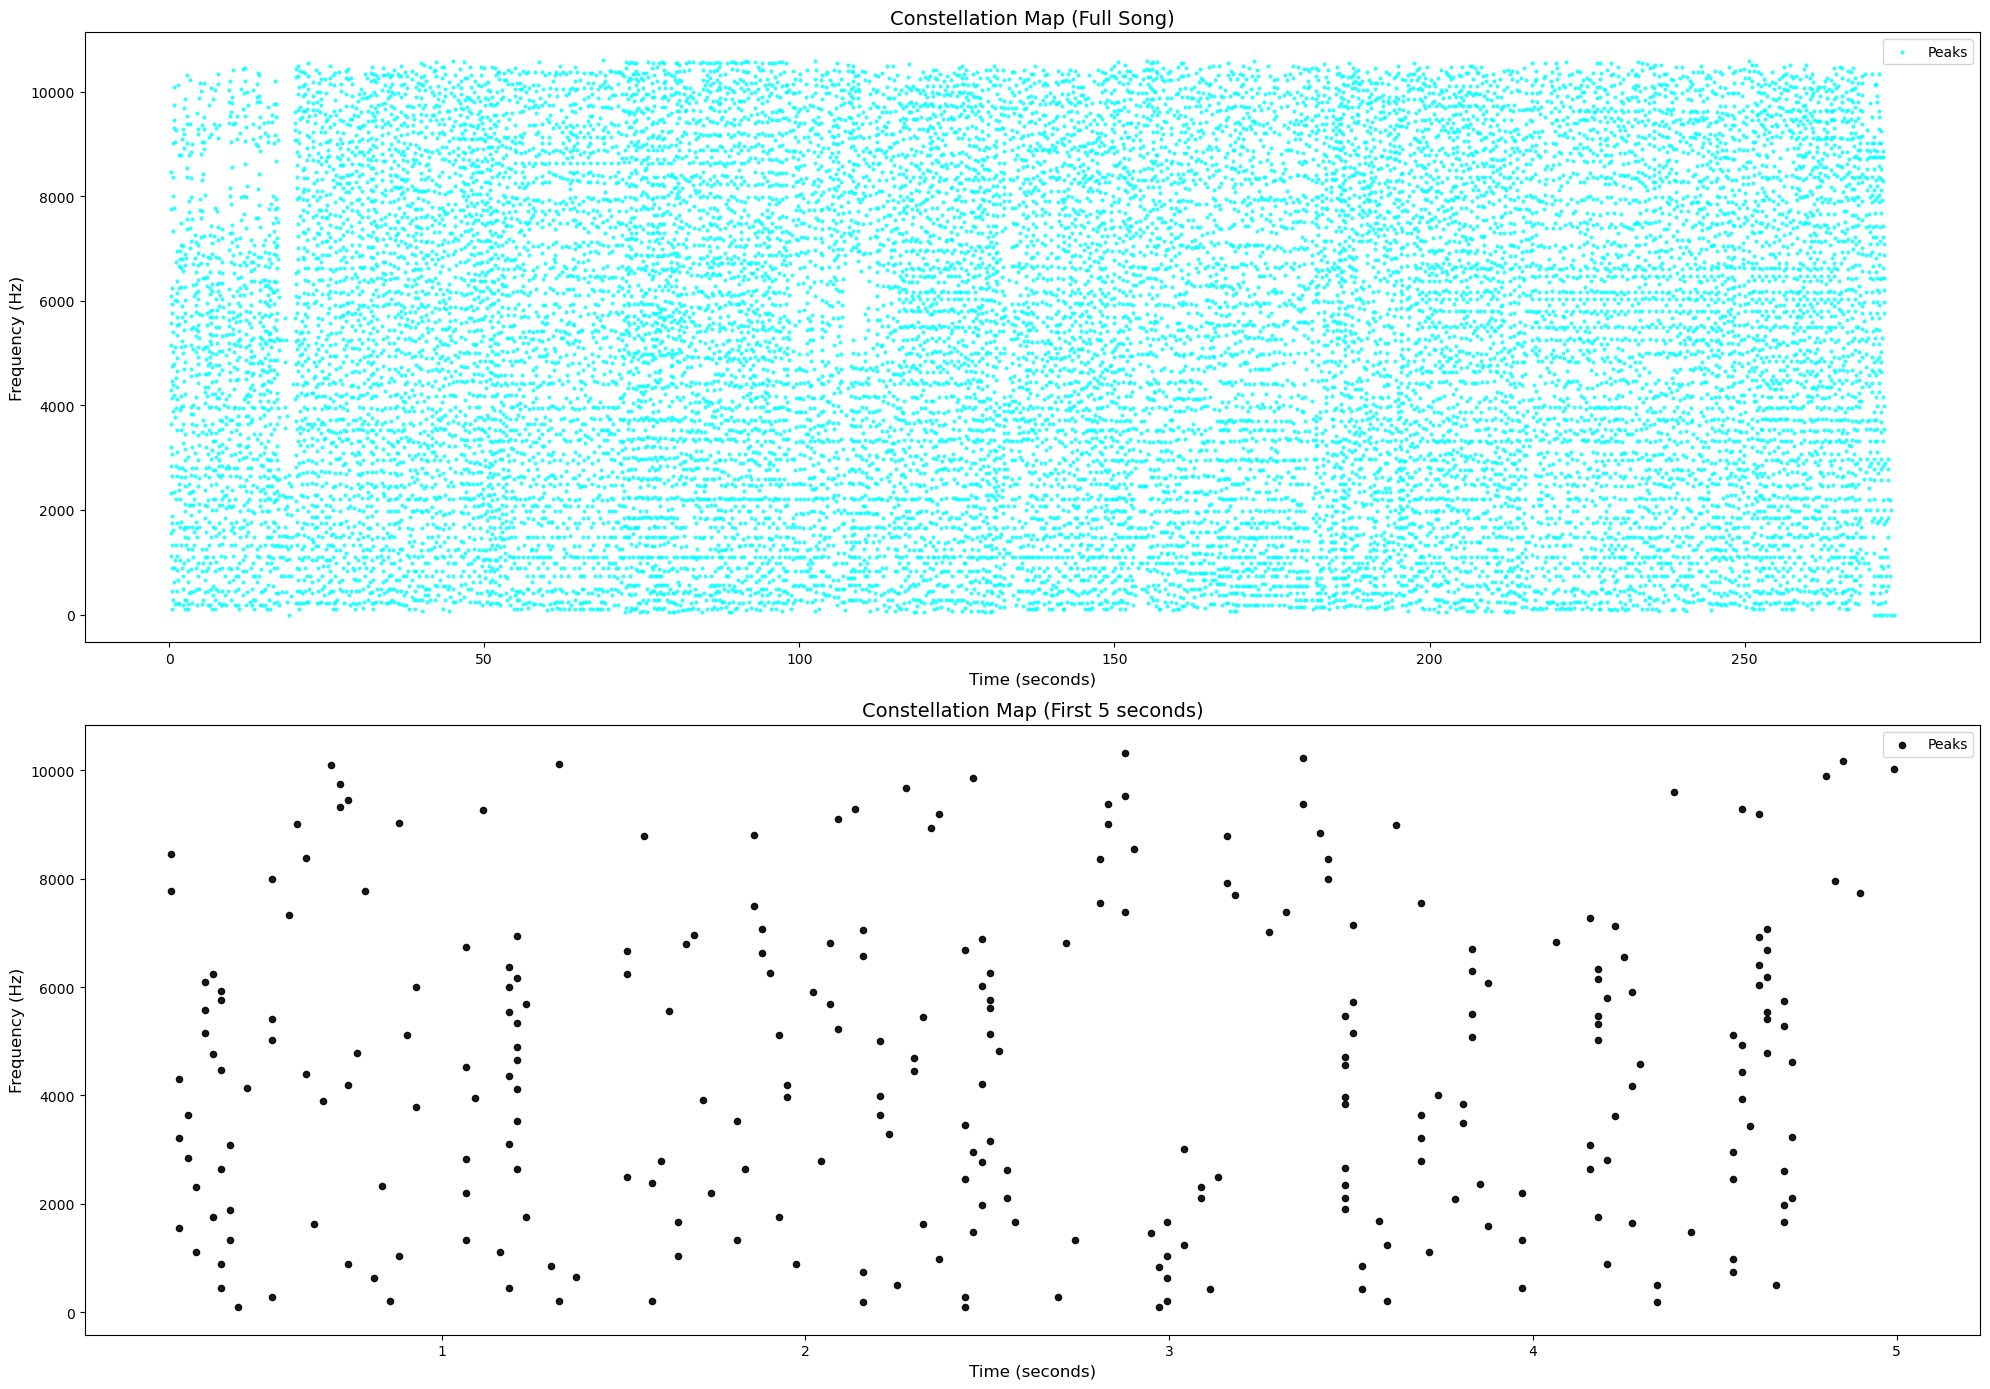

In [19]:

# Unpack peaks into frequency and time arrays
peak_freqs, peak_times = zip(*peaks)

# Convert frame indices to real-world units
times_sec = np.array(peak_times) * fp.hop_length / sr
freqs_hz  = np.array(peak_freqs) * (sr / fp.n_fft)

fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# --- Full constellation map ---
axes[0].scatter(times_sec, freqs_hz, s=4, color='cyan', alpha=0.7, label='Peaks')
axes[0].set_title("Constellation Map (Full Song)", fontsize=14)
axes[0].set_xlabel("Time (seconds)", fontsize=12)
axes[0].set_ylabel("Frequency (Hz)", fontsize=12)
axes[0].legend(loc='upper right')

# --- Zoomed view: first 5 seconds ---
zoom_sec = 5
mask = times_sec <= zoom_sec
axes[1].scatter(times_sec[mask], freqs_hz[mask], s=20, color='black', alpha=0.9, label='Peaks')
axes[1].set_title(f"Constellation Map (First {zoom_sec} seconds)", fontsize=14)
axes[1].set_xlabel("Time (seconds)", fontsize=12)
axes[1].set_ylabel("Frequency (Hz)", fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()
